# EDA for Featured Data

Notebook version του `src/02_eda_featured_data.py`.

Η λογική εδώ είναι ασφαλής για μεγάλα δεδομένα:
- τα βασικά summaries γίνονται με DuckDB πάνω στα parquet
- τα plots βασίζονται σε aggregated queries ή σε μικρό random sample
- δεν φορτώνεται όλο το featured dataset σε pandas

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'Notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FILES = [
    PROCESSED_DIR / 'chicago_featured.parquet',
    PROCESSED_DIR / 'nyc_featured.parquet',
]

for path in FILES:
    print(path)
    print('exists:', path.exists())

FILES_SQL = ', '.join(f"'{path.as_posix()}'" for path in FILES)
PARQUET_SOURCE = f"read_parquet([{FILES_SQL}])"

MIN_TRIP_DURATION_MIN = 1.0
MAX_TRIP_DURATION_MIN = 100.0
MIN_MOVING_DISTANCE_KM = 0.05
MAX_TRIP_DISTANCE_KM = 12.0

c:\Users\lefte\Desktop\GitHub Projects\Thesis_project\data\processed\chicago_featured.parquet
exists: True
c:\Users\lefte\Desktop\GitHub Projects\Thesis_project\data\processed\nyc_featured.parquet
exists: True


In [3]:
con = duckdb.connect()

def run_query(query: str) -> pd.DataFrame:
    return con.execute(query).fetchdf()

sample_query = f'''
SELECT
    city,
    trip_duration,
    haversine_distance_km,
    rideable_type,
    member_casual,
    hour,
    part_of_day,
    same_station
FROM {PARQUET_SOURCE}
USING SAMPLE 200000 ROWS
'''

sample_df = run_query(sample_query)
sample_df.head()

,city,trip_duration,haversine_distance_km,rideable_type,member_casual,hour,part_of_day,same_station
0,chicago,38.8667,6.8746,classic_bike,member,7,morning_peak,0
1,nyc,5.4833,1.2115,electric_bike,member,22,night,0
2,nyc,7.3500,1.1656,classic_bike,member,15,midday,0
3,nyc,5.8833,1.0250,electric_bike,member,17,evening_peak,0
4,nyc,6.4167,0.5004,electric_bike,member,14,midday,0


## Basic summaries

In [4]:
basic_summary = run_query(f'''
SELECT
    city,
    COUNT(*) AS n_rows,
    AVG(trip_duration) AS avg_duration,
    MEDIAN(trip_duration) AS median_duration,
    MIN(trip_duration) AS min_duration,
    MAX(trip_duration) AS max_duration,
    AVG(haversine_distance_km) AS avg_distance,
    MEDIAN(haversine_distance_km) AS median_distance,
    MIN(haversine_distance_km) AS min_distance,
    MAX(haversine_distance_km) AS max_distance
FROM {PARQUET_SOURCE}
GROUP BY city
ORDER BY city
''')

basic_summary

,city,n_rows,avg_duration,median_duration,min_duration,max_duration,avg_distance,median_distance,min_distance,max_distance
0,chicago,5547459,14.5735,9.4167,-54.7833,"1,499.9667",2.2028,1.6154,0.0000,40.5650
1,nyc,45623939,12.3444,8.8000,-58.9167,"1,499.9500",2.0028,1.4945,0.0000,"8,661.6811"


In [5]:
duration_percentiles = run_query(f'''
SELECT
    city,
    quantile_cont(trip_duration, 0.01) AS q01,
    quantile_cont(trip_duration, 0.05) AS q05,
    quantile_cont(trip_duration, 0.25) AS q25,
    quantile_cont(trip_duration, 0.50) AS median,
    quantile_cont(trip_duration, 0.75) AS q75,
    quantile_cont(trip_duration, 0.95) AS q95,
    quantile_cont(trip_duration, 0.99) AS q99
FROM {PARQUET_SOURCE}
GROUP BY city
ORDER BY city
''')

distance_percentiles = run_query(f'''
SELECT
    city,
    quantile_cont(haversine_distance_km, 0.01) AS q01,
    quantile_cont(haversine_distance_km, 0.05) AS q05,
    quantile_cont(haversine_distance_km, 0.25) AS q25,
    quantile_cont(haversine_distance_km, 0.50) AS median,
    quantile_cont(haversine_distance_km, 0.75) AS q75,
    quantile_cont(haversine_distance_km, 0.95) AS q95,
    quantile_cont(haversine_distance_km, 0.99) AS q99
FROM {PARQUET_SOURCE}
GROUP BY city
ORDER BY city
''')

duration_percentiles, distance_percentiles

(      city    q01    q05    q25  median     q75     q95     q99
 0  chicago 0.2667 2.0833 5.3833  9.4167 16.5333 39.3667 84.9167
 1      nyc 1.4500 2.4167 5.1667  8.8000 15.1333 32.1167 55.5000,
       city    q01    q05    q25  median    q75    q95    q99
 0  chicago 0.0000 0.0000 0.9081  1.6154 2.8792 6.1024 9.5346
 1      nyc 0.0000 0.3181 0.8599  1.4945 2.5976 5.4003 8.1912)

## Filtering impact

In [6]:
filter_impact = run_query(f'''
SELECT
    city,
    COUNT(*) AS total_rows,
    SUM(CASE
            WHEN trip_duration > {MIN_TRIP_DURATION_MIN}
             AND trip_duration < {MAX_TRIP_DURATION_MIN}
             AND (
                haversine_distance_km > {MIN_MOVING_DISTANCE_KM}
                OR same_station = 1
             )
             AND haversine_distance_km < {MAX_TRIP_DISTANCE_KM}
            THEN 1 ELSE 0
        END) AS rows_kept_by_filter,
    SUM(CASE
            WHEN NOT (
                trip_duration > {MIN_TRIP_DURATION_MIN}
                AND trip_duration < {MAX_TRIP_DURATION_MIN}
                AND (
                    haversine_distance_km > {MIN_MOVING_DISTANCE_KM}
                    OR same_station = 1
                )
                AND haversine_distance_km < {MAX_TRIP_DISTANCE_KM}
            )
            THEN 1 ELSE 0
        END) AS rows_removed_by_filter,
    ROUND(
        100.0 * SUM(CASE
            WHEN NOT (
                trip_duration > {MIN_TRIP_DURATION_MIN}
                AND trip_duration < {MAX_TRIP_DURATION_MIN}
                AND (
                    haversine_distance_km > {MIN_MOVING_DISTANCE_KM}
                    OR same_station = 1
                )
                AND haversine_distance_km < {MAX_TRIP_DISTANCE_KM}
            )
            THEN 1 ELSE 0
        END) / COUNT(*), 4
    ) AS pct_removed_by_filter
FROM {PARQUET_SOURCE}
GROUP BY city
ORDER BY city
''')

filter_impact

,city,total_rows,rows_kept_by_filter,rows_removed_by_filter,pct_removed_by_filter
0,chicago,5547459,"5,275,768.0000","271,691.0000",4.8976
1,nyc,45623939,"45,462,798.0000","161,141.0000",0.3532


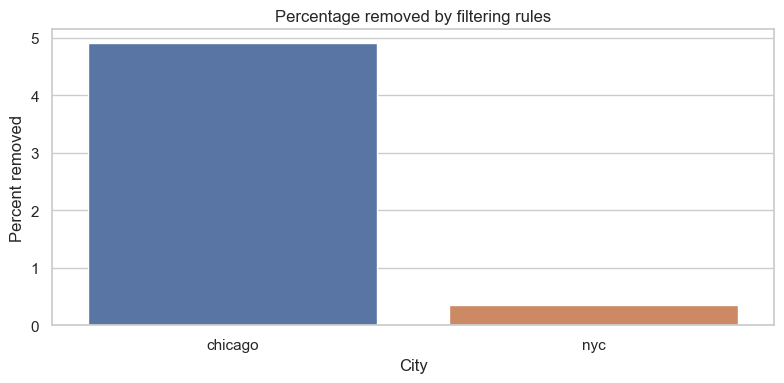

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(data=filter_impact, x='city', y='pct_removed_by_filter', hue='city', legend=False)
plt.title('Percentage removed by filtering rules')
plt.ylabel('Percent removed')
plt.xlabel('City')
plt.tight_layout()
plt.show()

## Temporal patterns

In [8]:
hour_distribution = run_query(f'''
SELECT city, hour, COUNT(*) AS n_trips
FROM {PARQUET_SOURCE}
GROUP BY city, hour
ORDER BY city, hour
''')

hour_distribution.head()

,city,hour,n_trips
0,chicago,0,71299
1,chicago,1,44892
2,chicago,2,28641
3,chicago,3,17129
4,chicago,4,16148


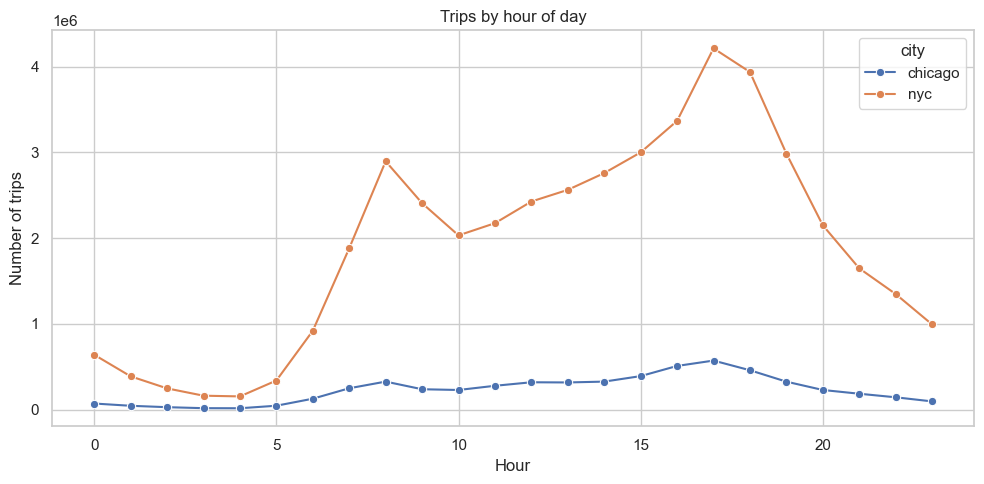

In [9]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=hour_distribution, x='hour', y='n_trips', hue='city', marker='o')
plt.title('Trips by hour of day')
plt.xlabel('Hour')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()

In [10]:
weekday_distribution = run_query(f'''
SELECT city, day_of_week, COUNT(*) AS n_trips
FROM {PARQUET_SOURCE}
GROUP BY city, day_of_week
ORDER BY city, day_of_week
''')

weekday_distribution

,city,day_of_week,n_trips
0,chicago,0,730399
1,chicago,1,788120
2,chicago,2,771123
3,chicago,3,833382
4,chicago,4,848147
5,chicago,5,863182
6,chicago,6,713106
7,nyc,0,6091140
8,nyc,1,6845644
9,nyc,2,6795947


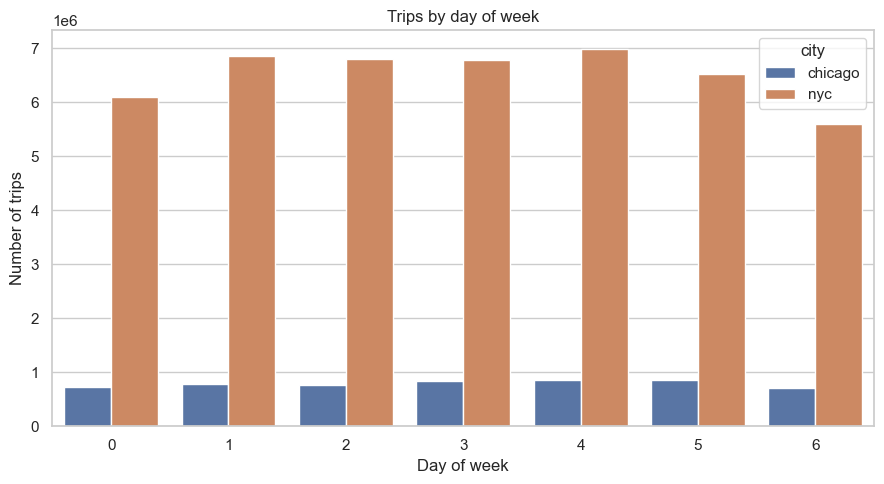

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(data=weekday_distribution, x='day_of_week', y='n_trips', hue='city')
plt.title('Trips by day of week')
plt.xlabel('Day of week')
plt.ylabel('Number of trips')
plt.tight_layout()
plt.show()

## User and ride type composition

In [12]:
member_distribution = run_query(f'''
SELECT city, member_casual, COUNT(*) AS n_trips
FROM {PARQUET_SOURCE}
GROUP BY city, member_casual
ORDER BY city, member_casual
''')

rideable_distribution = run_query(f'''
SELECT city, rideable_type, COUNT(*) AS n_trips
FROM {PARQUET_SOURCE}
GROUP BY city, rideable_type
ORDER BY city, rideable_type
''')

member_distribution, rideable_distribution

(      city member_casual   n_trips
 0  chicago        casual   1994849
 1  chicago        member   3552610
 2      nyc        casual   7933915
 3      nyc        member  37690024,
       city  rideable_type   n_trips
 0  chicago   classic_bike   1942506
 1  chicago  electric_bike   3604953
 2      nyc   classic_bike  13514590
 3      nyc  electric_bike  32109349)

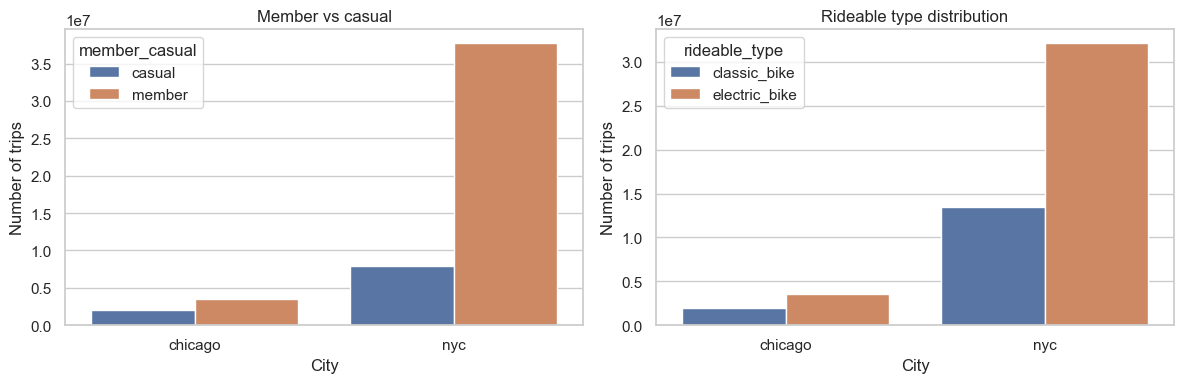

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=member_distribution, x='city', y='n_trips', hue='member_casual', ax=axes[0])
axes[0].set_title('Member vs casual')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Number of trips')

sns.barplot(data=rideable_distribution, x='city', y='n_trips', hue='rideable_type', ax=axes[1])
axes[1].set_title('Rideable type distribution')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Number of trips')

plt.tight_layout()
plt.show()

## Sample-based plots

Τα παρακάτω plots βασίζονται στο `sample_df`, όχι σε όλα τα rows.

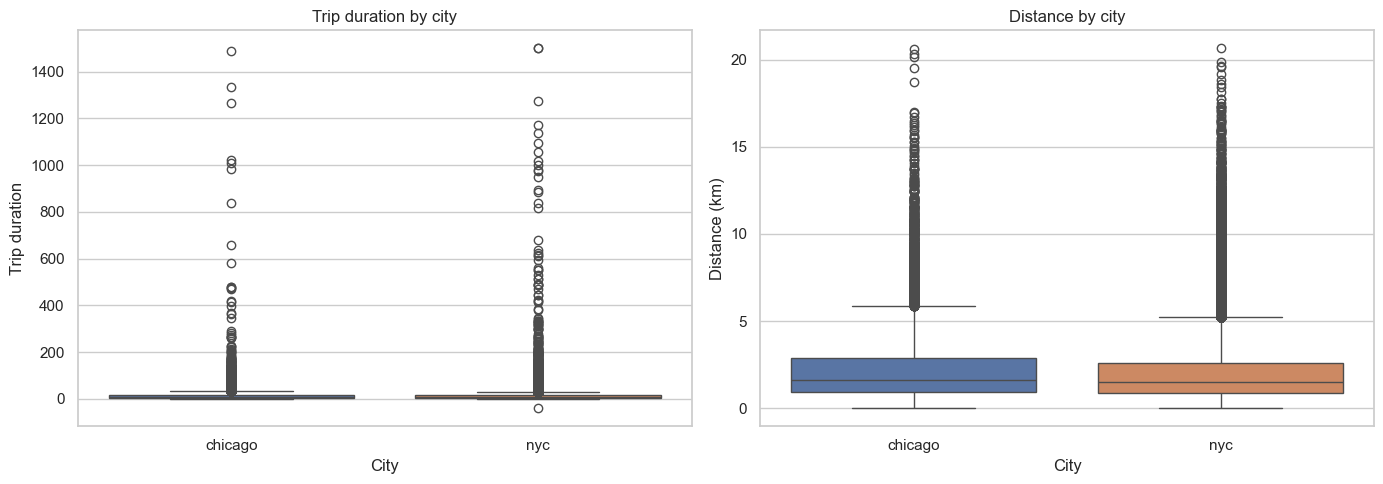

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=sample_df, x='city', y='trip_duration', hue='city', legend=False, ax=axes[0])
axes[0].set_title('Trip duration by city')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Trip duration')

sns.boxplot(data=sample_df, x='city', y='haversine_distance_km', hue='city', legend=False, ax=axes[1])
axes[1].set_title('Distance by city')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.show()

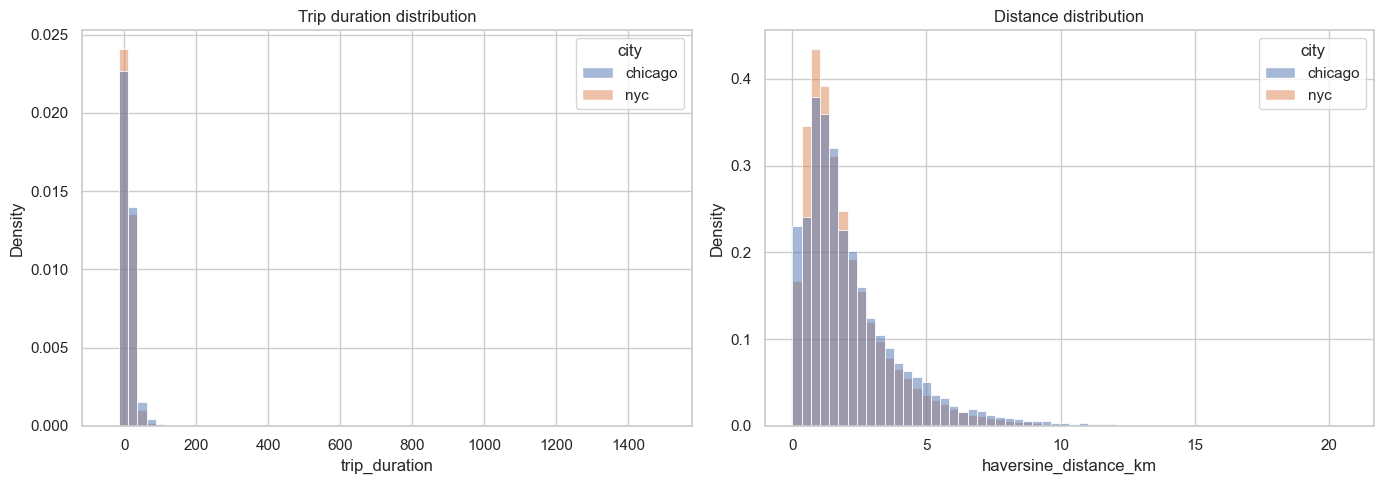

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=sample_df, x='trip_duration', hue='city', stat='density', common_norm=False, bins=60, ax=axes[0])
axes[0].set_title('Trip duration distribution')

sns.histplot(data=sample_df, x='haversine_distance_km', hue='city', stat='density', common_norm=False, bins=60, ax=axes[1])
axes[1].set_title('Distance distribution')

plt.tight_layout()
plt.show()

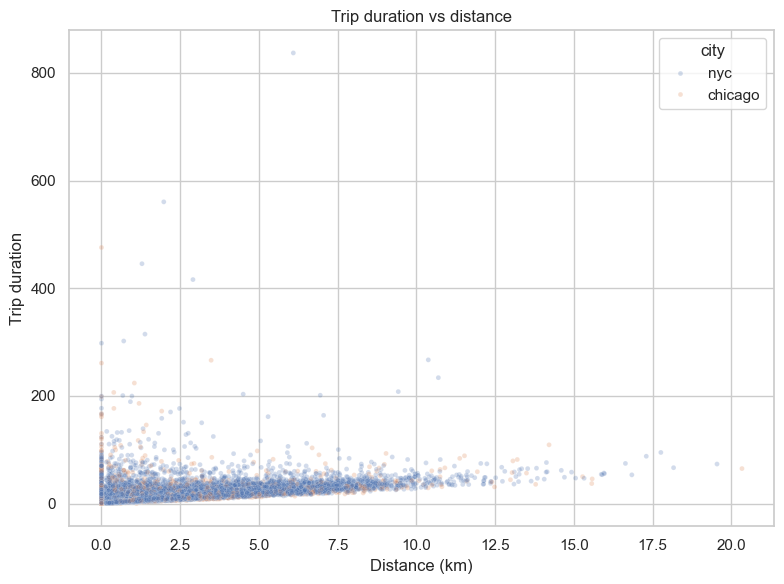

In [16]:
scatter_sample = sample_df.sample(min(len(sample_df), 30000), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_sample,
    x='haversine_distance_km',
    y='trip_duration',
    hue='city',
    alpha=0.25,
    s=12,
)
plt.title('Trip duration vs distance')
plt.xlabel('Distance (km)')
plt.ylabel('Trip duration')
plt.tight_layout()
plt.show()

## Correlations and suspicious cases

In [17]:
correlation_summary = run_query(f'''
SELECT
    city,
    CORR(trip_duration, hour) AS corr_duration_hour,
    CORR(trip_duration, haversine_distance_km) AS corr_duration_distance,
    CORR(haversine_distance_km, hour) AS corr_distance_hour
FROM {PARQUET_SOURCE}
GROUP BY city
ORDER BY city
''')

correlation_summary

,city,corr_duration_hour,corr_duration_distance,corr_distance_hour
0,chicago,0.0143,0.2322,0.0120
1,nyc,0.0257,0.1139,0.0009


In [18]:
suspicious_summary = run_query(f'''
SELECT
    city,
    CASE
        WHEN trip_duration <= {MIN_TRIP_DURATION_MIN} THEN 'too_short'
        WHEN trip_duration >= {MAX_TRIP_DURATION_MIN} THEN 'too_long'
        ELSE 'in_range'
    END AS duration_flag,
    CASE
        WHEN haversine_distance_km >= {MAX_TRIP_DISTANCE_KM} THEN 'too_far'
        WHEN haversine_distance_km <= {MIN_MOVING_DISTANCE_KM} AND same_station = 0 THEN 'too_short_non_same_station'
        WHEN haversine_distance_km <= {MIN_MOVING_DISTANCE_KM} AND same_station = 1 THEN 'same_station_near_zero'
        ELSE 'in_range'
    END AS distance_flag,
    COUNT(*) AS n_rows
FROM {PARQUET_SOURCE}
GROUP BY city, duration_flag, distance_flag
HAVING duration_flag <> 'in_range' OR distance_flag <> 'in_range'
ORDER BY city, n_rows DESC
''')

suspicious_summary

,city,duration_flag,distance_flag,n_rows
0,chicago,in_range,same_station_near_zero,149475
1,chicago,too_short,too_short_non_same_station,85226
2,chicago,in_range,too_short_non_same_station,71046
3,chicago,too_short,in_range,33215
4,chicago,too_short,same_station_near_zero,29404
5,chicago,too_long,in_range,27579
6,chicago,in_range,too_far,13917
7,chicago,too_long,same_station_near_zero,8900
8,chicago,too_long,too_far,1787
9,chicago,too_long,too_short_non_same_station,616


## Close connection

In [19]:
con.close()